In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib
import torch
import logging 
from pathlib import Path
import random
import numpy as np
from typing import cast

from method.datasets import Dataset, DatasetConfig, DatasetLoader
from method.preprocess.config import PreprocessConfig
from method.preprocess.preprocess import Preprocessor
from method.preprocess.split.splitter import Splitter, SplitterConfig
from method.core.pipeline import Pipeline
from method.models.rnn.rnn import RNNConfig, RNN
from method.metrics import metrics
from logging_tools.config import setup_logging
from method.viz import plot_data, plot_results

import data_configs.test_data_config as test_config
import data_configs.base_raw_data as config

CONFIGS_PATH = Path("configs")
DATASET_CONFIG = DatasetConfig.from_dict(config.EXECUTE_CONFIG["dataset"])

setup_logging()
logger = logging.getLogger(__name__)


INFO     Preprocessor: Start preprocessing

INFO     Preprocessor: Not NaN X, y                                                                                
             (8569, 327)

INFO     Filter: Data filtered

INFO     Scaler: Scaling completed

INFO     FeatureSelector: Selected features                                                                        
             '81TI10143'                                                                                           
             '81TI10126'                                                                                           
             '81FIL30066'                                                                                          
             '81LILH40012'                                                                                         
             '81TIH11209'                                                                                          
             '81FCL30063'                                                                                          
             '81FI30052'                                                                                           
             '81TI10123'

INFO     Preprocessor: Not NaN X, y                                                                                
             (8135, 282)

INFO     Preprocessor: Preprocessing completed

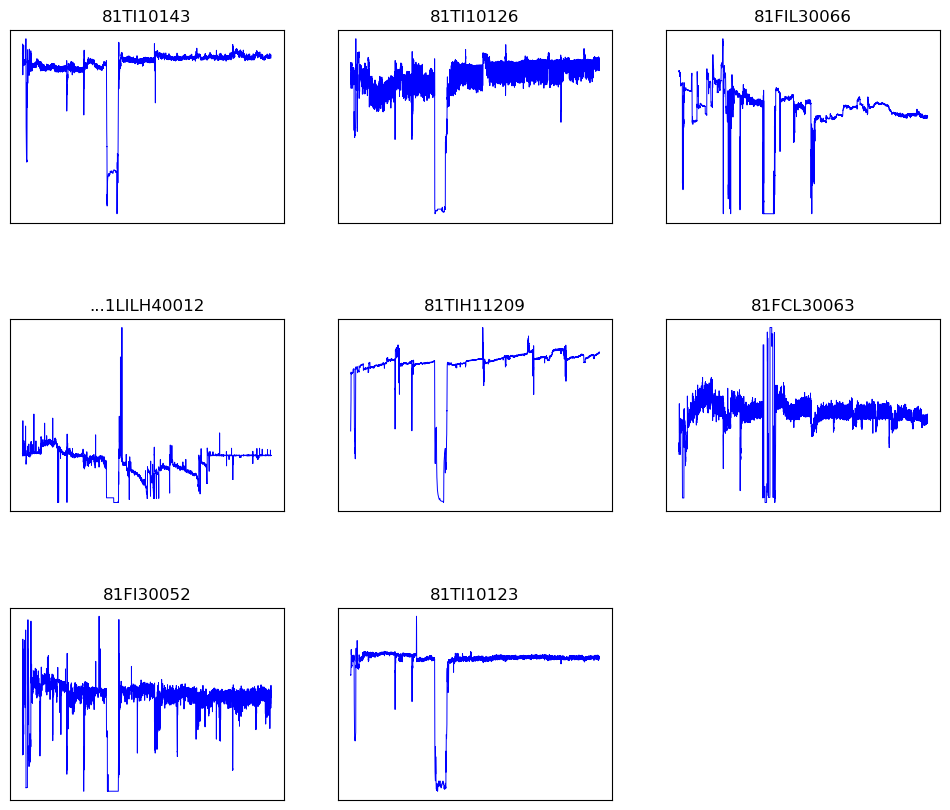

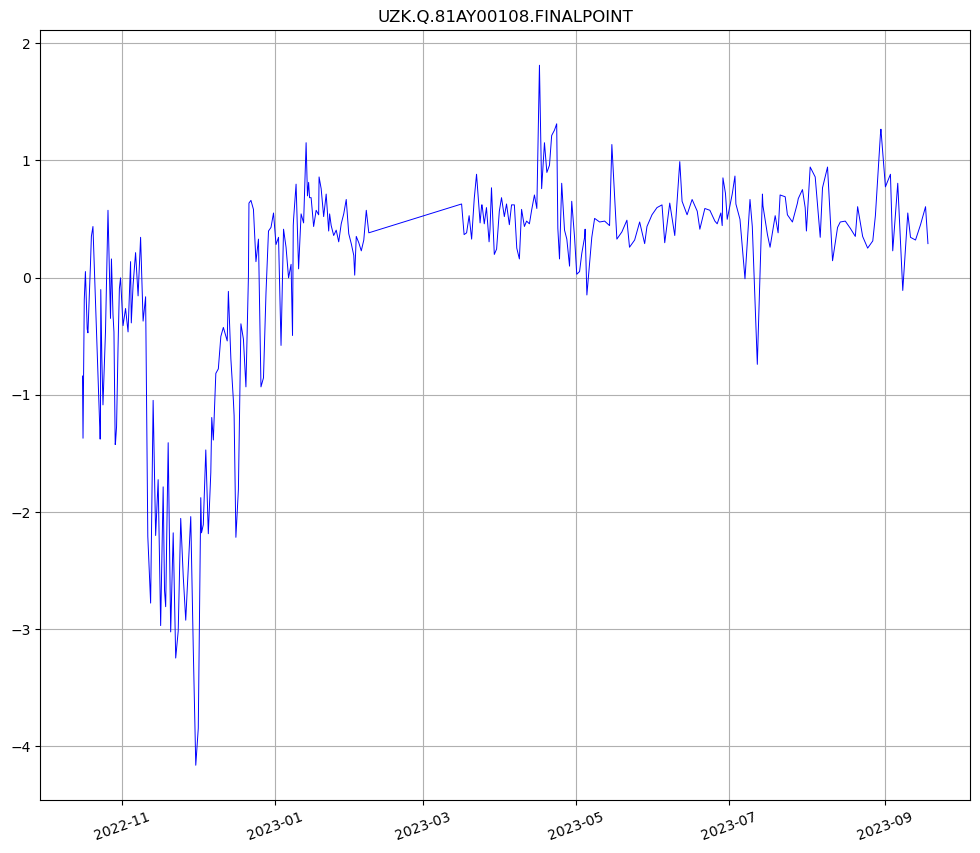

In [2]:
data = DatasetLoader(DATASET_CONFIG).load()

config.EXECUTE_CONFIG["preprocess"]["splitter"]["enabled"] = False
preprocess_config = PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
config.EXECUTE_CONFIG["preprocess"]["splitter"]["enabled"] = True

preprocessor = Preprocessor(preprocess_config)

data = preprocessor.fit_transform(data)
data = cast(Dataset, data)
plot_data(data.X.dropna(), plot_type="plot")
plot_data(data.y.dropna(), plot_type="plot")

INFO     Preprocessor: Start preprocessing

INFO     Preprocessor: Not NaN X, y                                                                                
             (8569, 327)

INFO     Filter: Data filtered

INFO     Scaler: Scaling completed

INFO     FeatureSelector: Selected features                                                                        
             '81TI10143'                                                                                           
             '81TI10126'                                                                                           
             '81FIL30066'                                                                                          
             '81LILH40012'                                                                                         
             '81TIH11209'                                                                                          
             '81FCL30063'                                                                                          
             '81FI30052'                                                                                           
             '81TI10123'

...

INFO     epoch 160: train: 0.1453, lr: 1.000e-02, valid: 0.1045, best_valid: 0.0637

INFO     epoch 170: train: 0.0897, lr: 1.000e-02, valid: 0.1586, best_valid: 0.0637

INFO     epoch 180: train: 0.1597, lr: 1.000e-02, valid: 0.1665, best_valid: 0.0637

INFO     epoch 190: train: 0.0894, lr: 1.000e-02, valid: 0.2191, best_valid: 0.0637

INFO     RNN: Model trained

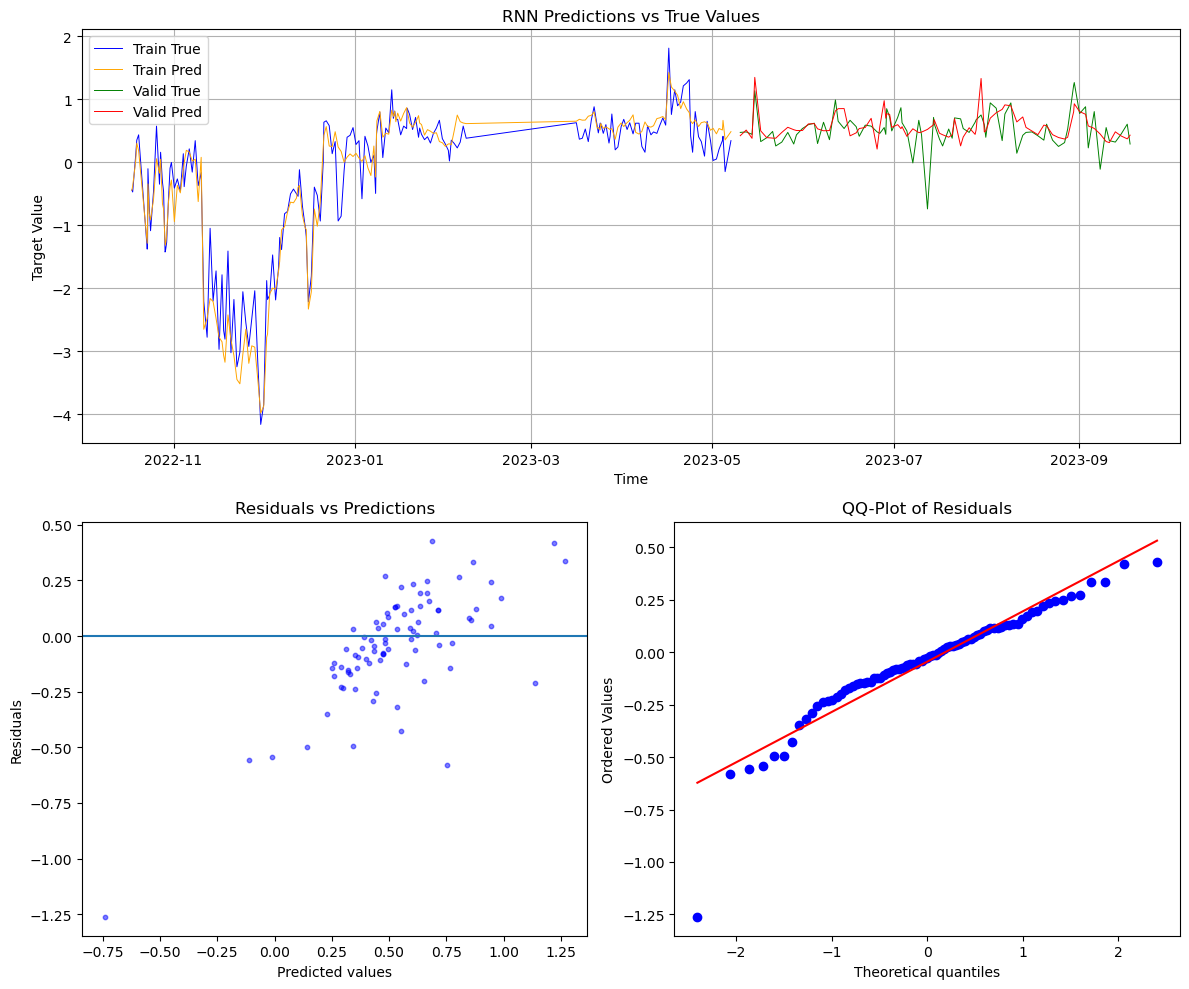

INFO                                                                                                               
         Metrics for Train:

INFO                                                                                                               
         Metrics for Valid:

INFO     MAE                  0.176207                                                                             
         rMSE                 0.252411                                                                             
         MAPE                 1.039513                                                                             
         Pearson (p-value)    0.000002                                                                             
         Pearson              0.488358                                                                             
         R2                   0.154241                                                                             
         Hinge                0.176207                                                                             
         dtype: float64

In [3]:

torch.manual_seed(0)
np.random.seed(42)
random.seed(42)

data = DatasetLoader(DATASET_CONFIG).load()

preprocess_config = PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
preprocessor = Preprocessor(preprocess_config)

splitter_config = SplitterConfig()
splitter = Splitter(splitter_config)

rnn_config = RNNConfig.from_dict(config.EXECUTE_CONFIG["model"])
rnn = RNN(rnn_config)

steps = [
    ("preprocessor", preprocessor),
    ("rnn", rnn),
]
full_pipeline = Pipeline(steps)

result = full_pipeline.fit_transform(data)

plot_results(result)

logger.info("\nMetrics for Train:")
logger.debug(metrics(**result["train"], cone=0))
logger.info("\nMetrics for Valid:")
logger.info(metrics(**result["valid"], cone=0))